In [102]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
import scipy

In [104]:
university_students = pd.read_csv('Documents/KStateSpring2025/MLAS390/Homework1/Kmeans_assignment_data.csv')
university_students.head()

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [105]:
print(university_students.columns)

Index(['Unnamed: 0', 'Private', 'Apps', 'Accept', 'Enroll', 'Top10perc',
       'Top25perc', 'F.Undergrad', 'P.Undergrad', 'Outstate', 'Room.Board',
       'Books', 'Personal', 'PhD', 'Terminal', 'S.F.Ratio', 'perc.alumni',
       'Expend', 'Grad.Rate'],
      dtype='object')


In [108]:
# Changing the name of column Unnamed: 0 to University.
university_students.rename(columns={'Unnamed: 0': 'University'}, inplace=True)

In [110]:
print(university_students.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   University   777 non-null    object 
 1   Private      777 non-null    object 
 2   Apps         777 non-null    int64  
 3   Accept       777 non-null    int64  
 4   Enroll       777 non-null    int64  
 5   Top10perc    777 non-null    int64  
 6   Top25perc    777 non-null    int64  
 7   F.Undergrad  777 non-null    int64  
 8   P.Undergrad  777 non-null    int64  
 9   Outstate     777 non-null    int64  
 10  Room.Board   777 non-null    int64  
 11  Books        777 non-null    int64  
 12  Personal     777 non-null    int64  
 13  PhD          777 non-null    int64  
 14  Terminal     777 non-null    int64  
 15  S.F.Ratio    777 non-null    float64
 16  perc.alumni  777 non-null    int64  
 17  Expend       777 non-null    int64  
 18  Grad.Rate    777 non-null    int64  
dtypes: float

# Observations from Info().

16 columns are int64, 2 columns are object, and 1 column float64.

S.F.Ratio is float64.

Unnamed: 0 and Private are objects which are strings.

In [113]:
print(university_students.shape)

(777, 19)


In [115]:
print(university_students.describe())

               Apps        Accept       Enroll   Top10perc   Top25perc  \
count    777.000000    777.000000   777.000000  777.000000  777.000000   
mean    3001.638353   2018.804376   779.972973   27.558559   55.796654   
std     3870.201484   2451.113971   929.176190   17.640364   19.804778   
min       81.000000     72.000000    35.000000    1.000000    9.000000   
25%      776.000000    604.000000   242.000000   15.000000   41.000000   
50%     1558.000000   1110.000000   434.000000   23.000000   54.000000   
75%     3624.000000   2424.000000   902.000000   35.000000   69.000000   
max    48094.000000  26330.000000  6392.000000   96.000000  100.000000   

        F.Undergrad   P.Undergrad      Outstate   Room.Board        Books  \
count    777.000000    777.000000    777.000000   777.000000   777.000000   
mean    3699.907336    855.298584  10440.669241  4357.526384   549.380952   
std     4850.420531   1522.431887   4023.016484  1096.696416   165.105360   
min      139.000000      

#### Observations from describe():

1. Apps mean and median is very far apart with mean at 3001.638353 and median at 1558.000000.

2. Accept mean and median is very far apart with mean at 2018.804376 and mean at 1110.000000.

3. Enroll mean and median is far apart with mean at 779.972973 and median at 434.000000.

4. Top10perc mean and median is close with mean at 27.558559 and median at 23.000000.

5. Top25perc mean and median is close with mean at 55.796654 and median at 54.000000.

6. F.Undergrad mean and median is very far apart with mean at 3699.907336 and median at 1707.000000.
 
7. P.Undergrad mean and median is far apart with mean at 855.298584 and median at 353.000000.

8. Outstate mean and median is far apart with mean at 10440.669241 and median at 9990.000000.

9. Room.Board mean and median is far apart with mean at 4357.526384 and median at 4200.000000.

10. Books mean and median is fairly close with mean at 549.380952 and median at 500.000000.

11. Personal mean and median is far apart with mean at 1340.642214 and median at 1200.000000.

12. PhD mean and median is close with mean at 72.660232 and median at 75.000000.

13. Terminal mean and median is close with mean at 79.702703 and median at 82.000000.

14. S.F.Ratio mean and median is very close with mean at 14.089704 and median at 13.600000.

15. perc.alumni mean and median is close with mean at 22.743887 and median at 21.000000.

16. Expend mean and median is far apart with mean at 9660.171171 and median at 8377.000000.

17. Grad.Rate mean and median is very close with mean at 65.46332 and median at 65.00000.

array([[<Axes: title={'center': 'Apps'}>,
        <Axes: title={'center': 'Accept'}>,
        <Axes: title={'center': 'Enroll'}>,
        <Axes: title={'center': 'Top10perc'}>],
       [<Axes: title={'center': 'Top25perc'}>,
        <Axes: title={'center': 'F.Undergrad'}>,
        <Axes: title={'center': 'P.Undergrad'}>,
        <Axes: title={'center': 'Outstate'}>],
       [<Axes: title={'center': 'Room.Board'}>,
        <Axes: title={'center': 'Books'}>,
        <Axes: title={'center': 'Personal'}>,
        <Axes: title={'center': 'PhD'}>],
       [<Axes: title={'center': 'Terminal'}>,
        <Axes: title={'center': 'S.F.Ratio'}>,
        <Axes: title={'center': 'perc.alumni'}>,
        <Axes: title={'center': 'Expend'}>],
       [<Axes: title={'center': 'Grad.Rate'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

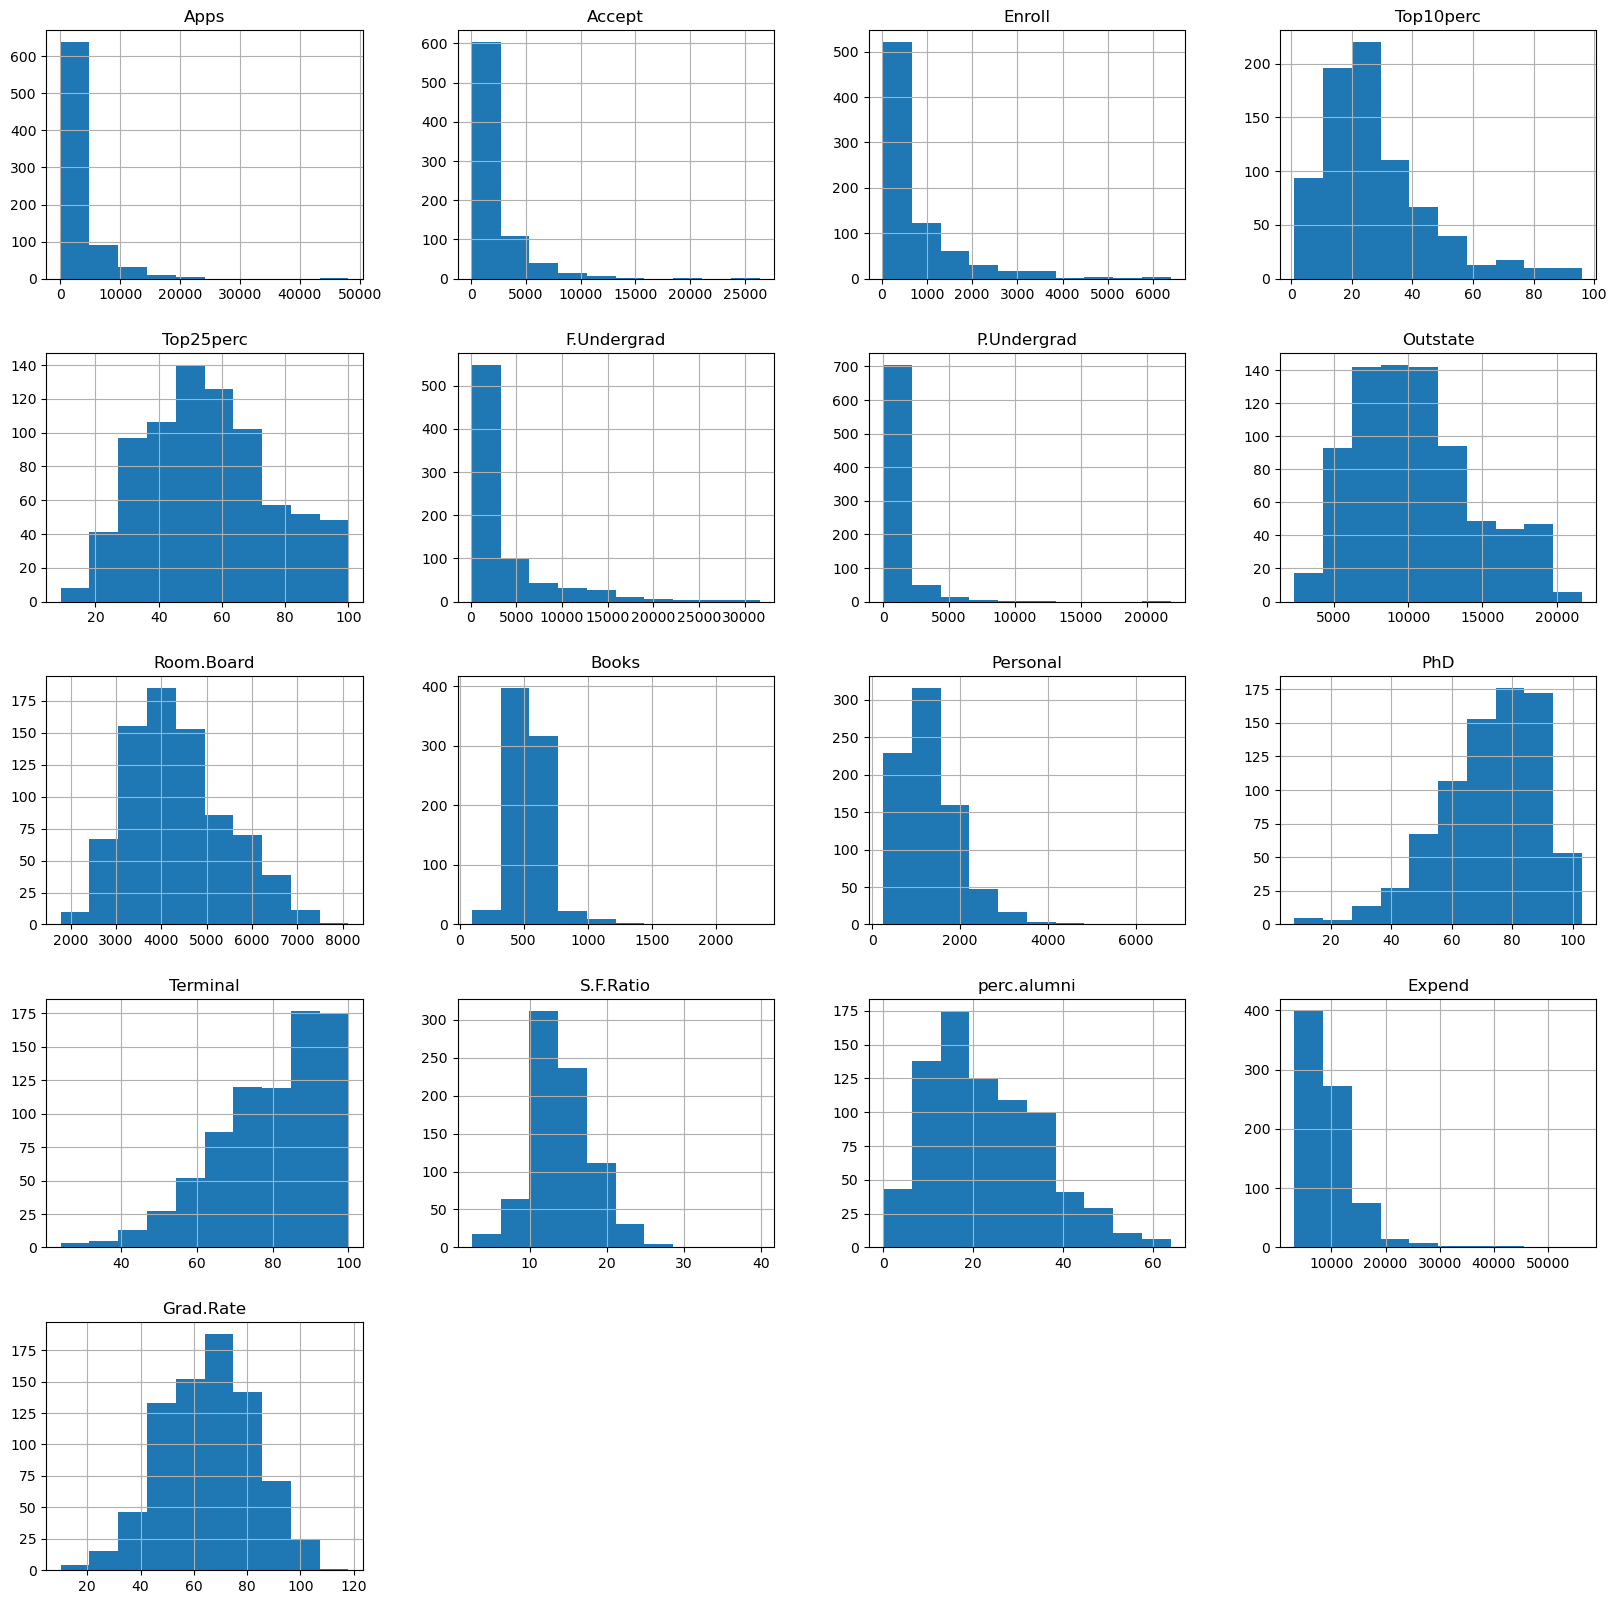

In [118]:
university_students.hist(figsize=(20,20))

#### Observations from histograms

1. A little more than 625 universities had less than 5,000 applicants. Nearly 100 universities had between 5,000 and 10,000 applicants. About 25 universities had more than 10,000 applicants.

2. Just over 600 universities had about 2500 applicants accepted. A little over 100 universities had just over 5,000 applicants accepted. A little over 30 universities had about 7,500 applicants accepted. Just over 10 universities had over 7,500 applicants accepted.

3. Around 525 universities had around 700 new students enroll. Around 125 universities had about 1250 new students enroll. Just over 60 universities had a little under 2000 new students enroll. About 30 universities had more than 2000 new students enroll.

4. Around 90 universities had about 10 new students from the top 10% of H.S. class. Just under 200 universities had 20 new students from the top 10% of H.S. class. Around 230 universities had about 30 new students from the top 10% of H.S. class. Around 120 universities had just under 40 new students from the top 10% of H.S. class. Around 65 universities had just under 50 new students from the top 10% of H.S. class. Around 40 universities had just under 60 new students from the top 10% of H.S. class. Around 20 universities had about 60 new students or more from the top 10% of H.S. class.

5. Less than 10 universities had just under 20 new students from the top 25% of H.S. class. Just over 40 universities had just under 25 new students from the top 25% of H.S. class. Just under 100 universities had about 38 new students from the top 25% of H.S. class. 140 universities had about 55 new students from the top 25% of H.S. class. Around 125 universities had just over 60 new students from the top 25% of H.S. class. Just over 100 universities had a little over 70 new students from the top 25% of H.S. class. A little over 60 universities had just over 80 new students from the top 25% of H.S. class. Just over 50 universities had about 90 new students from the top 25% of H.S. class. A litte under 50 universities had 100 new students from the top 25% of H.S. class.

6. A little more than 550 universities had around 3,750 full-time undergraduates. 100 universities had around 6,250 full-time undergraduates. Just under 50 universities universities had just under 10,000 fulltime undergraduates. Around 30 universities had around 12,250 fulltime undergraduates. Around 25 universities a little more than 15,000 fulltime undergraduates. Less than 10 universities had more than 15,000 fulltime undergraduates.

7. About 700 universities had about 2500 part-time undergraduates. About 50 universities had just under 5000 part-time undergraduates. Less than 10 universities had more than 5000 part-time undergraduates.

8. Just under 20 universities had students with out-of-state tuition a little under 5,000. Just over 90 universities had students with out-of-state tuition a little around 6,000. A little more than 140 universities had students with out-of-state tuition of around 7,000. A little more than 140 universities had students with out-of-state tuition at 10,000. A little more than 140 universities had students with out-of-state tuition of around 12,000. Around 50 universities had students with out-of-state tuition of around 16,500. A little more than 40 universities had students with out-of-state tuition a little more than 17,500. Around 45 universities had students with out-of-state tuition a little under 20,000. Less than 10 universities had students with out-of-state tuition over 20,000.

9. Just over 10 universities had room and board at a little less than 2,500. Around 70 universities had room and board at just over 3,000. Just over 150 universities had room and board at around 3,750. Just over 180 universities had room and board at about 4,250. Just over 150 universities had room and board at a little under 5,000. Around 85 universities had room and board at about 5,500. Around 70 universities had room and board at a little over 6,000. Just under 40 universities had room and board at a little under 7,000. Less than 15 universities had room and board at about 7,500.

10. About 25 universities estimated book costs are around 300. Just under 400 universities estimated book costs a little more than 500. About 320 universities estimated book costs are around 750. Around 25 universities estimated book costs about 1,000. Around 10 universities estimated book costs more than 1,000.

11. A little more than 225 universities have an estimated personal spending of about 1,000. Around 315 universities have an estimated personal spending of about 1,500. Just over 150 universities have an estimated personal spending of a little more than 2,000. About 50 universities have an estimated personal spending of a little less than 3,000. Around 20 universities have an estimated personal spending of more than 3000.

12. Just over 175 universities have a little more than 80 percent of faculty with Ph.D.'s. Just under 175 universities have a little more than 90 percent of faculty with Ph.D.'s. A little more than 150 universities have a little about 75 percent of faculty with Ph.D.'s. A little more than 100  universities have about 65 percent of faculty with Ph.D.'s. Around 70 universities have about 55 percent of faculty with Ph.D.'s. A little more than 50 universities have a little more than 100 percent of faculty with Ph.D.'s. A little more than 25 universities have a little less than 50 percent of faculty with Ph.D.'s. Around 15 universities have a little less than 40 percent of faculty with Ph.D.'s.

13. Just over 175 universities have a little more than 90 percent of faculty with terminal degrees. Around 175 universities have a little more than 100 percent of faculty with terminal degrees. About 120 universities have a little more than 75 percent of faculty with terminal degrees. About 120 universities have about 85 percent of faculty with terminal degrees. A little more than 85 universities have about 70 percent of their faculty with terminal degrees. Around 50 universities have a little more than 60 percent of faculty with terminal degrees. Just over 25 universities have a little more than 55 percent of faculty with terminal degrees. Less than 15 universities have less than 50 percent of faculty with terminal degrees.

14. Just over 300 universities have a student-to-faculty ratio of about 13. Around 240 universities have a student-to-faculty ratio of about 15. Around 125 universities have a student-to-faculty ratio of about 22. Around 60 universities have a student-to-faculty ratio of 10. A little more than 25 universities have a student-to-faculty ratio of 25. Around 20 universities have a student-to-faculty ratio of about 6. Less than 10 universities have a student-to-faculty ratio of more than 25.

15. 175 universities have just under 20 percent of alumni who donate. A little more than 100 universities have about 17 percent of alumni who donate. 125 universities have about 25 percent of alumni who donate. Around 110 universities have just under 35 percent of alumni who donate. 100 universities have about 38 percent of alumni who donate. A little over 40 universities have about 6 percent of alumni who donate. About 40 universities have about 44 percent of alumni who donate. Just over 25 universities have a little over 50 percent of alumni who donate. Less than 15 universities have more than 50 percent of alumni who donate.

16. 400 universities have an instructional expenditure per student of around 8,000. Around 275 universities have an instructional expenditure per student of around 14,000. Around 75 universities have an instructional expenditure per student of around 19,000. Around 20 universities have an instructional expenditure per student of more than 19,000.

17. Around 185 universities have a graduation rate of about 75 percent. Just over 150 universities have a graduation rate of about 65 percent. Around 135 universities have a graduation rate of about 85 percent. About 130 universities have a graduation rate of a litte over 50 percent. Around 70 universities have a graduation rate of about 95 percent. Around 45 universities have a graduation rate of about 40 percent. 25 universities have a graduation rate of about 108 percent. Around 15 universities have a graduation rate of less than 33 percent.

In [121]:
print(university_students.isnull().sum())

University     0
Private        0
Apps           0
Accept         0
Enroll         0
Top10perc      0
Top25perc      0
F.Undergrad    0
P.Undergrad    0
Outstate       0
Room.Board     0
Books          0
Personal       0
PhD            0
Terminal       0
S.F.Ratio      0
perc.alumni    0
Expend         0
Grad.Rate      0
dtype: int64


#### Observations of null values.

1. There are no null values.

#### Converting private catagorical feature to numeric

In [125]:
university_students['Private'] = university_students['Private'].map({"No":0, "Yes":1})

In [127]:
print(university_students['Private'].unique())

[1 0]


In [129]:
university_students.head()

,University,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,1,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,1,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,1,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,1,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,1,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [131]:
university_students = university_students.drop("University", axis=1)

In [133]:
university_students.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,1,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,1,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,1,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,1,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,1,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [135]:
print(university_students.describe())

          Private          Apps        Accept       Enroll   Top10perc  \
count  777.000000    777.000000    777.000000   777.000000  777.000000   
mean     0.727156   3001.638353   2018.804376   779.972973   27.558559   
std      0.445708   3870.201484   2451.113971   929.176190   17.640364   
min      0.000000     81.000000     72.000000    35.000000    1.000000   
25%      0.000000    776.000000    604.000000   242.000000   15.000000   
50%      1.000000   1558.000000   1110.000000   434.000000   23.000000   
75%      1.000000   3624.000000   2424.000000   902.000000   35.000000   
max      1.000000  48094.000000  26330.000000  6392.000000   96.000000   

        Top25perc   F.Undergrad   P.Undergrad      Outstate   Room.Board  \
count  777.000000    777.000000    777.000000    777.000000   777.000000   
mean    55.796654   3699.907336    855.298584  10440.669241  4357.526384   
std     19.804778   4850.420531   1522.431887   4023.016484  1096.696416   
min      9.000000    139.0000

In [137]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import numpy as np

import warnings 
warnings.filterwarnings('ignore')

(777, 18)


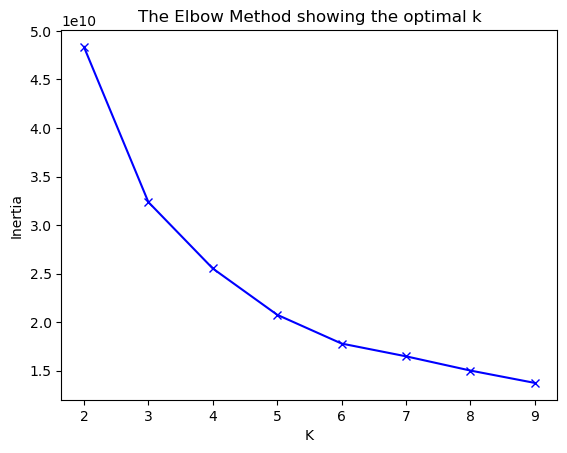

In [139]:
print(university_students.shape)
# k means determine k
inertia_list = []
K = range(2, 10)
for k in K:
    kmeanModel = KMeans(n_clusters=k, n_init="auto").fit(university_students)
    inertia_list.append(kmeanModel.inertia_)

# Plot the elbow
plt.plot(K, inertia_list, 'bx-')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('The Elbow Method showing the optimal k')
plt.show()

### Conclusion from the Elbow Method

The rate of change between K=4 and K=5 is higher, and it slows down between K=5 and K=6, so we can conclude that k=5 works better.

### Building a model with K=5

In [143]:
# Rerun the model with k=5

x = university_students

km = KMeans(
    n_clusters=5, init='random',
    n_init=10, max_iter=300, 
    tol=1e-04, random_state=0).fit(x)

In [145]:
print(x.shape)

(777, 18)


In [147]:
# Using the km model and grouping the data points

y_km = km.predict(x)

# Private, Apps, Accept, Enroll, Top10per, Top25perc, F.Undergrad, P.Undergrad, Outstate, Room.Board, Books, Personal, PhD, Terminal

print("Private, Apps, Accept, Enroll, Top10perc, Top25perc, F.Undergrad, P.Undergrad, Outstate, Room.Board, Books, Personal, PhD, Terminal")
print(km.cluster_centers_)

Private, Apps, Accept, Enroll, Top10perc, Top25perc, F.Undergrad, P.Undergrad, Outstate, Room.Board, Books, Personal, PhD, Terminal
[[1.00000000e+00 9.34175000e+03 3.60625000e+03 1.32195000e+03
  7.60500000e+01 9.17000000e+01 5.28320000e+03 4.27200000e+02
  1.81197500e+04 6.04275000e+03 5.76600000e+02 1.25555000e+03
  9.33000000e+01 9.68000000e+01 6.61500000e+00 3.53500000e+01
  3.23479000e+04 8.89500000e+01]
 [9.88505747e-01 2.49063793e+03 1.67400575e+03 5.13821839e+02
  3.93850575e+01 6.88965517e+01 2.04941954e+03 2.83385057e+02
  1.55319770e+04 5.23841379e+03 5.75293103e+02 1.06467241e+03
  8.31206897e+01 8.97816092e+01 1.15011494e+01 3.21321839e+01
  1.34827069e+04 7.67758621e+01]
 [8.28703704e-01 1.19294444e+03 9.01606481e+02 3.57932870e+02
  2.09212963e+01 4.80509259e+01 1.51548611e+03 5.04923611e+02
  9.05198380e+03 4.07788889e+03 5.29446759e+02 1.31178935e+03
  6.47546296e+01 7.25092593e+01 1.44868056e+01 2.10555556e+01
  7.55560648e+03 6.22916667e+01]
 [8.54700855e-02 5.837264

In [149]:
print(y_km.shape)
print(y_km)

(777,)
[2 1 2 1 2 2 2 1 1 2 1 1 2 2 2 2 1 2 2 2 0 3 2 4 2 2 2 3 2 2 2 2 2 2 2 2 1
 1 2 3 2 2 2 2 1 2 2 1 1 2 2 2 2 2 2 2 3 2 2 4 1 3 1 2 1 2 2 2 2 4 0 1 1 2
 1 2 2 2 3 3 2 2 2 2 2 2 1 0 2 2 2 1 2 2 1 2 1 2 2 2 1 2 3 3 3 2 1 1 1 2 2
 2 2 2 1 1 2 1 3 2 1 2 1 1 2 3 2 2 2 2 2 2 2 2 2 2 2 1 3 1 1 3 2 2 0 2 2 2
 2 1 2 1 1 2 2 2 2 2 0 1 2 2 1 1 1 2 2 2 2 2 2 1 1 2 0 1 3 3 2 2 2 3 2 2 1
 1 2 2 2 2 2 0 2 2 2 2 1 2 2 2 1 3 2 4 2 1 2 2 2 2 2 2 2 1 2 2 2 2 3 1 2 1
 3 3 2 1 2 2 2 2 1 2 2 3 2 2 2 1 2 2 1 2 1 1 1 3 2 2 2 1 0 1 2 2 1 1 1 3 1
 1 2 2 2 2 2 2 2 2 1 3 1 2 2 3 4 2 2 4 1 3 3 2 2 2 0 2 2 1 3 2 2 2 1 2 2 2
 1 2 2 1 2 1 2 3 2 2 1 2 2 1 2 2 2 1 2 2 2 2 2 2 2 2 2 2 3 3 1 1 2 1 2 2 2
 2 1 2 2 2 1 1 3 2 1 2 3 3 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 3 4 2 2 3
 2 2 2 2 2 3 2 2 2 1 2 2 3 3 2 3 1 2 2 2 1 2 2 2 2 2 2 1 2 2 1 3 2 2 2 2 2
 0 2 2 2 3 4 2 2 3 1 3 4 3 3 2 2 2 0 1 2 3 1 1 2 1 4 1 2 2 3 2 2 2 3 1 2 1
 2 4 1 2 2 2 2 2 2 1 2 2 1 2 2 0 1 4 2 2 2 3 2 1 1 1 1 1 1 1 1 2 1 2 2 2 1
 2 3 4 2 3 2 2 2 3

In [151]:
print(type(y_km))

<class 'numpy.ndarray'>


In [153]:
#reshaping ykm

ykm = y_km.reshape(-1,1)

In [155]:
print(ykm.shape)
print(ykm[0:20])

(777, 1)
[[2]
 [1]
 [2]
 [1]
 [2]
 [2]
 [2]
 [1]
 [1]
 [2]
 [1]
 [1]
 [2]
 [2]
 [2]
 [2]
 [1]
 [2]
 [2]
 [2]]


In [157]:
# Adding a new column with the group number

university_students["Group"] = ykm

In [159]:
print(university_students.head())

   Private  Apps  Accept  Enroll  Top10perc  Top25perc  F.Undergrad  \
0        1  1660    1232     721         23         52         2885   
1        1  2186    1924     512         16         29         2683   
2        1  1428    1097     336         22         50         1036   
3        1   417     349     137         60         89          510   
4        1   193     146      55         16         44          249   

   P.Undergrad  Outstate  Room.Board  Books  Personal  PhD  Terminal  \
0          537      7440        3300    450      2200   70        78   
1         1227     12280        6450    750      1500   29        30   
2           99     11250        3750    400      1165   53        66   
3           63     12960        5450    450       875   92        97   
4          869      7560        4120    800      1500   76        72   

   S.F.Ratio  perc.alumni  Expend  Grad.Rate  Group  
0       18.1           12    7041         60      2  
1       12.2           16   1052

In [161]:
centroids = km.cluster_centers_ 
print(centroids)

labels = km.labels_
print(labels)

[[1.00000000e+00 9.34175000e+03 3.60625000e+03 1.32195000e+03
  7.60500000e+01 9.17000000e+01 5.28320000e+03 4.27200000e+02
  1.81197500e+04 6.04275000e+03 5.76600000e+02 1.25555000e+03
  9.33000000e+01 9.68000000e+01 6.61500000e+00 3.53500000e+01
  3.23479000e+04 8.89500000e+01]
 [9.88505747e-01 2.49063793e+03 1.67400575e+03 5.13821839e+02
  3.93850575e+01 6.88965517e+01 2.04941954e+03 2.83385057e+02
  1.55319770e+04 5.23841379e+03 5.75293103e+02 1.06467241e+03
  8.31206897e+01 8.97816092e+01 1.15011494e+01 3.21321839e+01
  1.34827069e+04 7.67758621e+01]
 [8.28703704e-01 1.19294444e+03 9.01606481e+02 3.57932870e+02
  2.09212963e+01 4.80509259e+01 1.51548611e+03 5.04923611e+02
  9.05198380e+03 4.07788889e+03 5.29446759e+02 1.31178935e+03
  6.47546296e+01 7.25092593e+01 1.44868056e+01 2.10555556e+01
  7.55560648e+03 6.22916667e+01]
 [8.54700855e-02 5.83726496e+03 4.02947009e+03 1.73959829e+03
  2.23675214e+01 5.35811966e+01 9.25682906e+03 2.27493162e+03
  7.03694017e+03 3.75233333e+03 5

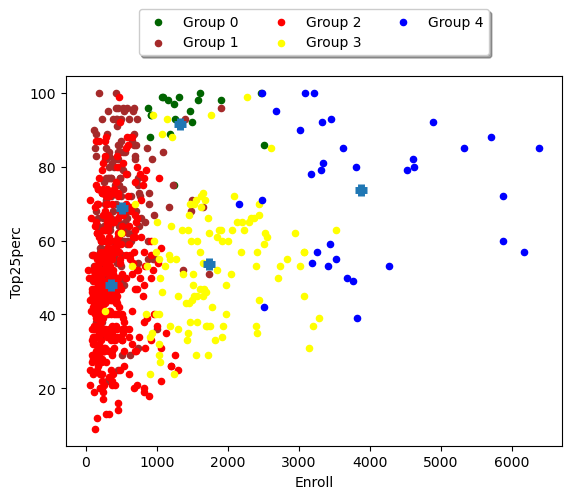

In [163]:
## to plot the centroids, we use [:,3] and [:,5]

group0 = x[x['Group']==0].plot(kind='scatter', x='Enroll', y='Top25perc', color='DarkGreen', label="Group 0")
group1 = x[x['Group']==1].plot(kind='scatter', x='Enroll', y='Top25perc', color='Brown', ax=group0, label="Group 1")
group2 = x[x['Group']==2].plot(kind='scatter', x='Enroll', y='Top25perc', color='Red', ax=group0, label="Group 2")
group3 = x[x['Group']==3].plot(kind='scatter', x='Enroll', y='Top25perc', color='Yellow', ax=group0, label="Group 3")
group4 = x[x['Group']==4].plot(kind='scatter', x='Enroll', y='Top25perc', color='Blue', ax=group0, label="Group 4")

group0.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=3, fancybox=True, shadow=True)
plt.scatter(centroids[:,3], centroids[:,5], marker="+", s=80, linewidths=5)
plt.show()

In [165]:
'''
Private = 1, Apps = 1000, Accept = 800, Enroll = 765, Top10perc = 20, Top25perc = 44, F.Undergrad = 2300, P.Undergrad = 480, Outstate = 13000, 
Room.Board = 3800, Books = 390, Personal = 1700, Ph.D. = 65, Terminal = 78, S.F.Ratio = 15, perc.alumni = 22, Expend = 9000, Grad.Rate = 52
Want to know to which group this point belongs to:
'''

x = np.array([[1, 1000, 800, 765, 20, 44, 2300, 480, 13000, 3800, 390, 1700, 65, 78, 15, 22, 9000, 52]])

y_km = km.predict(x)
print(y_km)

[2]


### Conclusion after doing a predict on the new data point

A person in Private school with Private = 1, Apps = 1000, Accept = 800, Enroll = 765, Top10perc = 20, Top25perc = 44,
F.Undergrad = 2300, P.Undergrad = 480, Outstate = 13000, Room.Board = 3800, Books = 390, Personal = 1700, Ph.D. = 65, Terminal = 78 
belongs to group 2.